### Polynomial Linear Regression

You can try using different regression model to see what case can be solved by polynomial regression. This can be solved using different power on variable.  

### $y = b_0 + b_1x_1 + b_2x_1^2 + ... + b_nx_1^n$

#### When we can use it?

When your data on liner regression looks curved which doesn't seems fit well on regression line then you can consider polynomial regression like below image

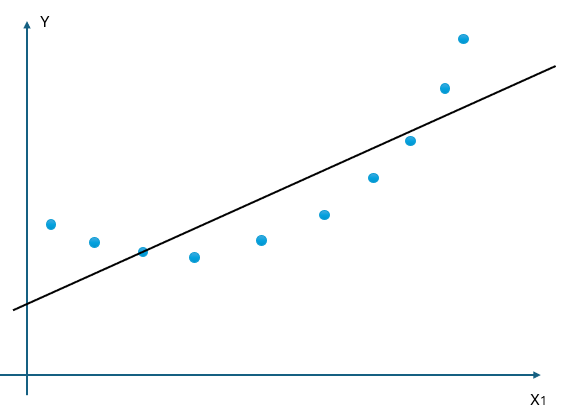

So, it's clearly not fit to line, so in this case we can use our polynomial regression like below which will better fit and formula for that given up above.

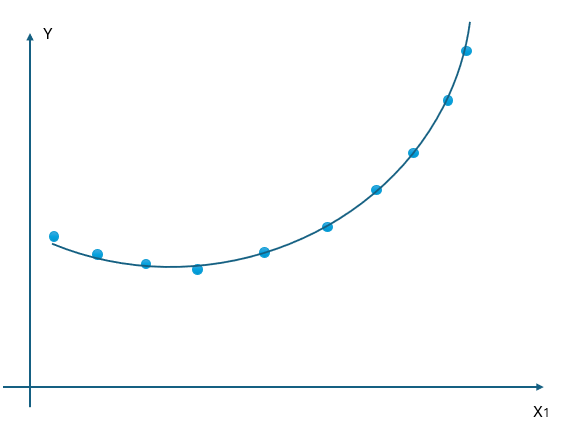

We are going to use Position_Salaries.csv file dataset. Let's imaging a following secenario, if we hire someone and person salary expectation asking $160000 and reasoning for that high salary because he was earning that much in his previous company. Now we will try to find if that is possibly true or not with our existing datasets collected from many other sources.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
data = pd.read_csv('Data/Position_Salaries.csv')

X = data.iloc[:, 1:-1].values # 1:-1 means we are taking all the rows and all the columns except the last one, means we are keeping the last column as our dependent variable
y = data.iloc[:, -1].values

data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [13]:
#x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
regression = LinearRegression()
regression.fit(X, y)

LinearRegression()

Now you are noticing that when we tried to use linear regression, it is not fitting properly therefore it's required to try using different model to find the correct fit.

### Training the polynomial regression model on the whole dataset

In [18]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=4)
x_poly = poly_reg.fit_transform(X)
print(x_poly)
regression2 = LinearRegression()
regression2.fit(x_poly, y)

[[1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01]
 [1.000e+00 3.000e+00 9.000e+00 2.700e+01 8.100e+01]
 [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02]
 [1.000e+00 5.000e+00 2.500e+01 1.250e+02 6.250e+02]
 [1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03]
 [1.000e+00 7.000e+00 4.900e+01 3.430e+02 2.401e+03]
 [1.000e+00 8.000e+00 6.400e+01 5.120e+02 4.096e+03]
 [1.000e+00 9.000e+00 8.100e+01 7.290e+02 6.561e+03]
 [1.000e+00 1.000e+01 1.000e+02 1.000e+03 1.000e+04]]


LinearRegression()

### Visualize the linear regression

Text(0, 0.5, 'Salary')

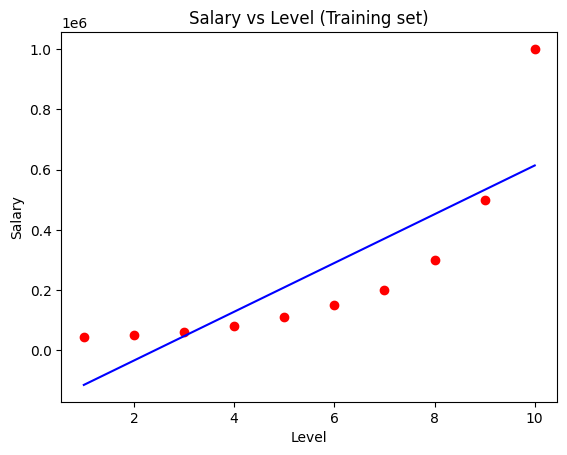

In [15]:
plt.scatter(X, y, color='red')
plt.plot(X, regression.predict(X), color='blue')
plt.title('Salary vs Level (Training set)')
plt.xlabel('Level')
plt.ylabel('Salary')

### Visualize the polynomial regression

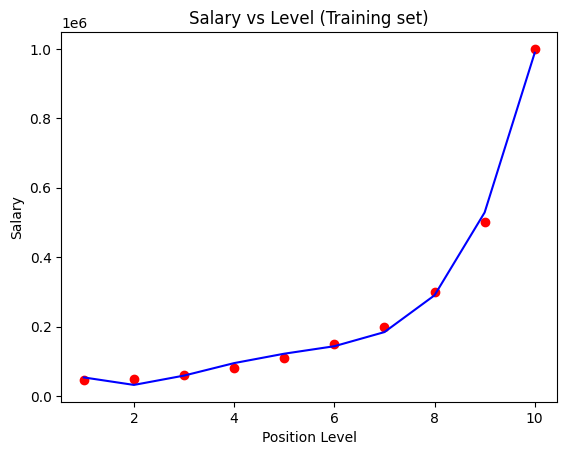

In [19]:
plt.scatter(X, y, color='red')
plt.plot(X, regression2.predict(poly_reg.fit_transform(X)), color='blue')
plt.title('Salary vs Level (Training set)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

### Visualizing the polynomial regression results

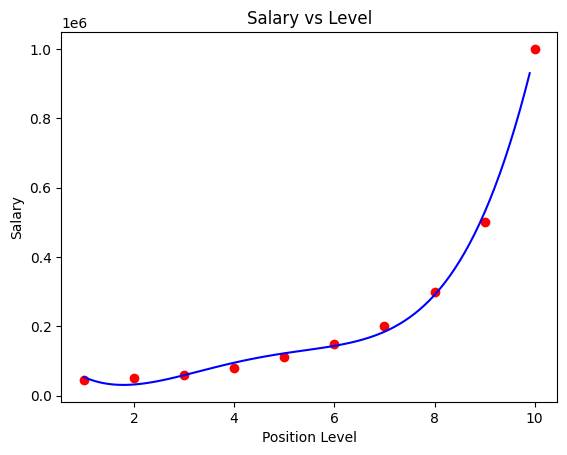

In [21]:
x_grid = np.arange(min(X), max(X), 0.1)
x_grid = x_grid.reshape((len(x_grid), 1))
plt.scatter(X, y, color='red')
plt.plot(x_grid, regression2.predict(poly_reg.fit_transform(x_grid)), color='blue')
plt.title('Salary vs Level')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

### Predicting a new result with linear regression

In [ ]:
regression.predict([[6.5]]) # this won't work because of linear regression model and a Bad prediction

array([330378.78787879])

### Predicting a new result with Polynomial Regression

In [26]:
regression2.predict(poly_reg.fit_transform([[6.5]]))

array([158862.45265155])